In [4]:
from __future__ import annotations

import sys, os
sys.path.append(os.path.abspath(".."))

# Данные

In [5]:
from torch_geometric.data import Dataset, Data
import torch
import numpy as np
import pandas as pd
from scipy import stats

вспомогательные функции для построения матрицы смежности

In [6]:
def pearson_matrix(df: pd.DataFrame) -> np.ndarray:
  """Корреляция Пирсона между всеми парами признаков."""
  return df.corr(method='pearson').values

def spearman_matrix(df: pd.DataFrame) -> np.ndarray:
  """Ранговая корреляция Спирмена (устойчива к выбросам)."""
  return df.corr(method='spearman').values

def mutual_info_matrix(df: pd.DataFrame) -> np.ndarray:
  """
  Нормированная взаимная информация (NMI) через оценку плотности.
  Симметрична, лежит в [0, 1].
  """
  n_features = df.shape[1]
  mi = np.zeros((n_features, n_features))
  arr = df.values.astype(np.float32)
  for i in range(n_features):
    for j in range(i + 1, n_features):
      # kernel-density оценка двумерной MI через корреляцию Спирмена
      # (быстрое приближение без sklearn)
      r, _ = stats.spearmanr(arr[:, i], arr[:, j])
      r = np.clip(r, -1 + 1e-9, 1 - 1e-9)
      nmi = abs(r) # приближение: |r| ≈ NMI для монотонных связей
      mi[i, j] = nmi
      mi[j, i] = nmi

  np.fill_diagonal(mi, 1.0)
  return mi

def partial_corr_matrix(df: pd.DataFrame) -> np.ndarray:
  """
  Частичная корреляция через обращение корреляционной матрицы.
  Показывает прямую связь между парой переменных при фиксации остальных.
  """
  corr = df.corr(method='pearson').values
  try:
    inv = np.linalg.pinv(corr)
    d = np.sqrt(np.diag(inv))
    partial = -inv / np.outer(d, d)
    np.fill_diagonal(partial, 1.0)
    return np.abs(partial)
  except np.linalg.LinAlgError:
    return np.abs(corr)

EDGE_STRATEGIES = {
  'pearson':      pearson_matrix,
  'spearman':     spearman_matrix,
  'mutual_info':  mutual_info_matrix,
  'partial_corr': partial_corr_matrix,
}

In [7]:
class PolyFilmDataset(Dataset):
  def __init__(
    self,
    df: pd.DataFrame,
    target_col: str = 'target',
    edge_strategy: str | list[str] = 'pearson',
    threshold: float = 0.3,
    self_loops: bool = False,
    normalize_features: bool = True,
  ):
    super().__init__()

    self._feature_cols: list[str] = [c for c in df.columns if c != target_col]
    self._n_nodes: int = len(self._feature_cols)

    feature_df = df[self._feature_cols].copy().astype(np.float32)
    labels = df[target_col].values.astype(np.int64)

    if normalize_features:
      self._mean = feature_df.mean()
      self._std = feature_df.std().replace(0, 1)
      feature_df = (feature_df - self._mean) / self._std
    else:
      self._mean = None
      self._std = None

    self._features: np.ndarray = feature_df.values
    self._labels: np.ndarray = labels

    strategies = [edge_strategy] if isinstance(edge_strategy, str) else edge_strategy
    for s in strategies:
      if s not in EDGE_STRATEGIES:
        raise ValueError(
          f"Неизвестная стратегия '{s}'. "
          f"Доступные: {list(EGDE_STRATEGIES)}"
        )

    weight_matrices = [
      np.abs(EDGE_STRATEGIES[s](feature_df))
      for s in strategies
    ]

    combined: np.ndarray = np.mean(weight_matrices, axis=0)
    np.fill_diagonal(combined, 0.0)

    src, dst = np.where(combined >= threshold)
    edge_weights = combined[src, dst].astype(np.float32)

    if self_loops:
      loop_idx = np.arange(self._n_nodes)
      src = np.concatenate([src, loop_idx])
      dst = np.concatenate([dst, loop_idx])
      edge_weights = np.concatenate([edge_weights, np.ones(self._n_nodes)])

    self._edge_index: torch.Tensor = torch.tensor(
      np.stack([src, dst], axis=0), dtype=torch.long
    )
    self._edge_attr: torch.Tensor = torch.tensor(
      edge_weights,  dtype=torch.float32
    ).unsqueeze(1)

  def len(self) -> int:
    return len(self._labels)

  def get(self, idx: int) -> Data:
    """
    Возвращает граф для одного наблюдения.

    Граф:
    x          — (N_nodes, 1)  значения признаков для данного наблюдения
    edge_index — (2, E)        индексы рёбер (общие для всех графов)
    edge_attr  — (E, 1)        веса рёбер (общие для всех графов)
    y          — (1,)          бинарная метка
    """

    # Значения признаков текущего наблюдения — каждый узел получает своё число
    node_features = torch.tensor(
      self._features[idx], dtype=torch.float32
    ).unsqueeze(1)

    label = torch.tensor(self._labels[idx], dtype=torch.long)

    return Data(
      x             = node_features,
      edge_index    = self._edge_index,
      edge_attr     = self._edge_attr,
      y             = label,
      num_nodes     = self._n_nodes,
    )

  @property
  def num_node_features(self) -> int:
    return 1

  @property
  def num_classes(self) -> int:
    return 2

  @property
  def feature_names(self) -> list[str]:
    return self._feature_cols

  @property
  def num_edges(self) -> int:
    return self._edge_index.shape[1]

  def __repr__(self) -> str:
    return (
      f"{self.__class__.__name__}("
      f"samples={self.len()}, "
      f"nodes={self._n_nodes}, "
      f"edges={self.num_edges})"
    )

# Модель

In [8]:
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_geometric.nn import (
  GATv2Conv,
  GraphNorm,
  global_add_pool,
  global_mean_pool,
  global_max_pool,
)
from torch_geometric.data import Batch

In [9]:
class GATBlock(nn.Module):
  """
  Один слой графового внимания с нормализацией и остаточным соединением.

  Parameters
  ----------
  in_channels : int
  out_channels : int      размерность выхода на голову (head)
  heads : int             число голов внимания
  dropout : float         вероятность dropout на веса внимания и активации
  edge_dim : int | None   размерность edge_attr; None — не используется
  residual : bool         добавлять ли skip-connection
  """
  def __init__(
    self,
    in_channels: int,
    out_channels: int,
    heads: int = 4,
    dropout: float = 0.3,
    edge_dim: int | None = 1,
    residual: bool = True,
  ):
    super().__init__()

    self.conv = GATv2Conv(
      in_channels   = in_channels,
      out_channels  = out_channels,
      heads         = heads,
      dropout       = dropout,
      edge_dim      = edge_dim,
      concat        = True,
      add_self_loops= False,
    )

    out_total = out_channels * heads
    self.norm = GraphNorm(out_total)
    self.dropout = nn.Dropout(p=dropout)

    self.residual = residual
    if residual and in_channels != out_total:
      self.skip = nn.Linear(in_channels, out_total, bias=False)
    else:
      self.skip = None

  def forward(
    self,
    x: Tensor,
    edge_index: Tensor,
    edge_attr: Tensor | None = None,
    batch: Tensor | None = None,
  ) -> Tensor:
    out = self.conv(x, edge_index, edge_attr=edge_attr)
    out = self.norm(out, batch)
    out = F.elu(out)
    out = self.dropout(out)

    if self.residual:
      res = self.skip(x) if self.skip is not None else x
      out = out + res

    return out

In [10]:
class PolymerGAT(nn.Module):
  """
  Графовая сеть внимания для бинарной классификации дефектов плёнки.

  Схема прохождения данных:
      x  →  InputProjection  →  GATBlock × n_layers
         →  GlobalPooling (mean + max + add)
         →  BatchNorm  →  Linear  →  Dropout  →  Linear(2)

  Parameters
  ----------
  in_channels : int
      Размерность признака узла из датасета (обычно 1).
  hidden_channels : int
      Число скрытых каналов на голову в каждом GAT-слое.
  n_layers : int
      Число GATBlock-слоёв (рекомендуется 2–4).
  heads : int
      Число голов внимания.
  dropout : float
      Dropout в GAT-блоках и классификационной голове.
  edge_dim : int | None
      Размерность edge_attr. Передать None, чтобы игнорировать веса рёбер.
  pooling : str
      Стратегия глобального пулинга: "mean", "max", "add", "concat".
      "concat" объединяет mean + max + add → более богатое представление.
  """
  def __init__(
    self,
    in_channels: int = 1,
    hidden_channels: int = 32,
    n_layers: int = 3,
    heads: int = 4,
    dropout: float = 0.3,
    edge_dim: int | None = 1,
    pooling: str = 'concat',
  ):
    super().__init__()

    if n_layers < 1:
      raise ValueError('n_layers должно быть >= 1')

    self.pooling = pooling

    self.input_proj = nn.Sequential(
      nn.Linear(in_channels, hidden_channels),
      nn.LayerNorm(hidden_channels),
      nn.ELU(),
    )

    self.gat_blocks = nn.ModuleList()
    in_ch = hidden_channels
    for _ in range(n_layers):
      block = GATBlock(
        in_channels=in_ch,
        out_channels=hidden_channels,
        heads=heads,
        dropout=dropout,
        edge_dim=edge_dim,
        residual=True,
      )
      self.gat_blocks.append(block)
      in_ch = hidden_channels * heads

    graph_embed_dim = in_ch * 3 if pooling == 'concat' else in_ch

    self.classifier = nn.Sequential(
      nn.LayerNorm(graph_embed_dim),
      nn.Linear(graph_embed_dim, hidden_channels*2),
      nn.ELU(),
      nn.Dropout(p=dropout),
      nn.Linear(hidden_channels*2, 1),
    )

  def forward(self, data: Data | Batch) -> Tensor:
    """
    Parameters
    ----------
    data : torch_geometric.data.Data | Batch
        Граф или батч графов из DataLoader.

    Returns
    -------
    Tensor  shape (B, 2) — логиты классов
    """
    x, edge_index, edge_attr, batch = (
      data.x,
      data.edge_index,
      data.edge_attr,
      data.batch,
    )

    x = self.input_proj(x)

    for block in self.gat_blocks:
      x = block(x, edge_index, edge_attr, batch)

    if self.pooling == 'concat':
      graph_emb = torch.cat([
        global_mean_pool(x, batch),
        global_max_pool(x, batch),
        global_add_pool(x, batch),
      ], dim=-1)
    elif self.pooling == 'mean':
      graph_emb = global_mean_pool(x, batch)
    elif self.pooling == 'max':
      graph_emb = global_max_pool(x, batch)
    elif self.pooling == 'add':
      graph_emb = global_add_pool(x, batch)
    else:
      raise ValueError(f'Неизвестый pooling: {self.pooling!r}')

    logits = self.classifier(graph_emb)

    return logits

  @torch.no_grad()
  def predict_proba(self, data: Data | Batch) -> Tensor:
    """Возвращает вероятности классов (B, 2)."""
    self.eval()
    return torch.sigmoid(self(data)).squeeze(1)

  @torch.no_grad()
  def predict(self, data: Data | Batch, threshold: float = 0.5) -> Tensor:
    """Возвращает предсказанный класс (B,)."""
    return (self.predict_proba(data) >= threshold).long()

  def count_parameters(self) -> int:
    return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [11]:
def build_model(
  in_channels: int = 1,
  hidden_channels: int = 32,
  n_layers: int = 3,
  heads: int = 4,
  dropout: float = 0.4,
  edge_dim: int | None = 1,
  pooling: str = 'concat',
) -> PolymerGAT:
  """Создаёт и возвращает инициализированную модель."""
  model = PolymerGAT(
    in_channels     =in_channels,
    hidden_channels =hidden_channels,
    n_layers        =n_layers,
    heads           =heads,
    dropout         =dropout,
    edge_dim        =edge_dim,
    pooling         =pooling,
  )

  return model

In [12]:
from typing import NamedTuple

class SplitResult(NamedTuple):
  train: pd.DataFrame
  val: pd.DataFrame
  test: pd.DataFrame

In [13]:
def stratified_split(
  df: pd.DataFrame,
  target_col: str = 'target',
  train_size: float = 0.70,
  val_size: float = 0.15,
  test_size: float = 0.15,
  random_state: int = 42,
  verbose: bool = True,
) -> SplitResult:
  """
  Делит DataFrame на train / val / test с сохранением доли классов.

  Parameters
  ----------
  df : pd.DataFrame
      Исходный датафрейм со всеми признаками и целевой переменной.
  target_col : str
      Название столбца с бинарной меткой (0 / 1).
  train_size, val_size, test_size : float
      Доли разбиения. Должны в сумме давать 1.0.
  random_state : int
      Зерно генератора для воспроизводимости.
  verbose : bool
      Печатать ли статистику по сплитам.

  Returns
  -------
  SplitResult(train, val, test) — три DataFrame с reset_index.
  """
  if not np.isclose(train_size + val_size + test_size, 1.0):
    raise ValueError(
      f'Сумма долей должна быть 1.0'
      f'получено {train_size + val_size + test_size:.4f}'
    )

  if target_col not in df.columns:
    raise KeyError(f"Стобец '{target_col}' не найден в DataFrame")

  unique_classes = df[target_col].unique()
  if not set(unique_classes).issubset({0.0, 1.0}):
    raise ValueError(f"Ожидаются только значения 0 и 1 в '{target_col}'")

  rng = np.random.default_rng(random_state)

  idx_pos = df.index[df[target_col] == 1].to_numpy().copy()
  idx_neg = df.index[df[target_col] == 0].to_numpy().copy()

  rng.shuffle(idx_pos)
  rng.shuffle(idx_neg)

  def _split_indices(idx: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Режет массив индексов на три части по заданным пропорциям."""
    n = len(idx)
    n_train = int(np.floor(n * train_size))
    n_val = int(np.floor(n * val_size))
    return idx[:n_train], idx[n_train:n_train + n_val], idx[n_train + n_val:]

  train_pos, val_pos, test_pos = _split_indices(idx_pos)
  train_neg, val_neg, test_neg = _split_indices(idx_neg)

  def _make_split(pos: np.ndarray, neg: np.ndarray) -> pd.DataFrame:
    combined = np.concatenate([pos, neg])
    rng.shuffle(combined)
    return df.loc[combined].reset_index(drop=True)

  train_df = _make_split(train_pos, train_neg)
  val_df = _make_split(val_pos, val_neg)
  test_df = _make_split(test_pos, test_neg)

  if verbose:
    _print_split_stats(df, train_df, val_df, test_df, target_col)

  return SplitResult(train=train_df, val=val_df, test=test_df)

def _print_split_stats(
  original: pd.DataFrame,
  train: pd.DataFrame,
  val: pd.DataFrame,
  test: pd.DataFrame,
  target_col: str,
):
  total = len(original)

  header = f"{'Сплит':<10} {'Строк':>7} {'% от всех':>10} {'Дефекты':>9} {'% дефектов':>12}"
  sep = '─' * len(header)

  print(sep)
  print(header)
  print(sep)

  for name, df in [('Исходный', original), ('Train', train), ('Val', val), ('Test', test)]:
    n = len(df)
    pct = 100 * n / total
    n_pos = (df[target_col] == 1).sum()
    pct_pos = 100 * n_pos / n if n > 0 else 0.0
    print(f"{name:<10} {n:>7,}  {pct:>9.1f}%  {n_pos:>8,}  {pct_pos:>10.1f}%")

    print(sep)

# Цикл обучения

In [14]:
import csv
import time
from pathlib import Path
from dataclasses import dataclass, field, asdict
from torch_geometric.loader import DataLoader
from torch.utils.data import WeightedRandomSampler

@dataclass
class EpochMetrics:
  epoch:     int
  phase:     str          # "train" | "val" | "test"
  loss:      float

  # Классификационные метрики
  precision: float = 0.0
  recall:    float = 0.0
  f1:        float = 0.0
  accuracy:  float = 0.0

  duration_sec: float = 0.0

  def __str__(self) -> str:
    return (
        f"[{self.phase.upper():>5}] epoch={self.epoch:>3d} | "
        f"loss={self.loss:.4f}  "
        f"prec={self.precision:.4f}  rec={self.recall:.4f}  "
        f"f1={self.f1:.4f}  acc={self.accuracy:.4f}  "
        f"({self.duration_sec:.1f}s)"
    )

def compute_metrics(
  epoch: int,
  phase: str,
  loss: float,
  y_true: np.ndarray,      # (N,)  int  0/1
  y_prob: np.ndarray,      # (N,)  float  P(class=1)
  y_pred: np.ndarray,      # (N,)  int  0/1
  duration_sec: float,
) -> EpochMetrics:
  """
  Считает все метрики по собранным за эпоху предсказаниям.

  Регрессионные метрики применяются к вероятностям y_prob vs y_true,
  что позволяет оценить качество калибровки модели.
  """

  # ── Классификационные метрики (жёсткие предсказания) ────────────────────
  tp = int(np.sum((y_pred == 1) & (y_true == 1)))
  fp = int(np.sum((y_pred == 1) & (y_true == 0)))
  fn = int(np.sum((y_pred == 0) & (y_true == 1)))
  tn = int(np.sum((y_pred == 0) & (y_true == 0)))

  precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
  f1        = (
      2 * precision * recall / (precision + recall)
      if (precision + recall) > 0 else 0.0
  )
  accuracy  = (tp + tn) / len(y_true) if len(y_true) > 0 else 0.0

  return EpochMetrics(
    epoch        = epoch,
    phase        = phase,
    loss         = loss,
    precision    = float(precision),
    recall       = float(recall),
    f1           = float(f1),
    accuracy     = float(accuracy),
    duration_sec = duration_sec,
  )

In [15]:
class MetricsLogger:
  def __init__(self, log_path: str | Path | None = None):
    self.log_path = Path(log_path) if log_path else None
    if self.log_path is not None:
      with self.log_path.open('w') as f:
        pass

    self._csv_initialized = False
    self.history: list[EpochMetrics] = []

  def log(self, metrics: EpochMetrics):
    self.history.append(metrics)
    print(metrics)

    if self.log_path is not None:
      row = asdict(metrics)
      write_header = not self._csv_initialized and not self.log_path.exists()
      with self.log_path.open('a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
          writer.writeheader()
        writer.writerow(row)
      self._csv_initialized = True

  def best(self, phase: str = 'val', key: str = 'recall', mode: str = 'max') -> EpochMetrics:
    subset = [m for m in self.history if m.phase == phase]
    if not subset:
      raise ValueError(f"Нет записей для фазы '{phase}'")
    return min(subset, key=lambda m: getattr(m, key)) if mode == 'min' \
    else max(subset, key=lambda m: getattr(m, key))

In [16]:
def make_weighted_sampler(
  labels: np.ndarray,
  pos_ratio: float = 0.3,
) -> WeightedRandomSampler:
  """
  Создаёт сэмплер, который в среднем даёт `pos_ratio` дефектов в батче.

  Parameters
  ----------
  labels    : бинарный массив меток (0/1) обучающей выборки
  pos_ratio : желаемая доля дефектов в батче
  """
  n = len(labels)
  n_pos = labels.sum()
  n_neg = n - n_pos

  if n_pos == 0:
    raise ValueError("В обучающей выборке нет ни одного дефекта")

  w_pos = pos_ratio / n_pos
  w_neg = (1.0 - pos_ratio) / n_neg
  weights = np.where(labels == 1, w_pos, w_neg)

  return WeightedRandomSampler(
    weights= torch.tensor(weights, dtype=torch.float64),
    num_samples = n,
    replacement = True,
  )

In [17]:
def _run_epoch(
  model: PolymerGAT,
  loader: DataLoader,
  criterion: nn.Module,
  device: torch.device,
  threshold: float,
  optimizer: torch.optim.Optimizer | None = None,
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
  """
  Выполняет один проход по DataLoader.

  Returns
  -------
  avg_loss, y_true, y_prob, y_pred
  """
  is_train = optimizer is not None
  model.train(is_train)
  ctx = torch.enable_grad() if is_train else torch.no_grad()

  total_loss = 0.0
  all_true, all_prob, all_pred = [], [], []

  with ctx:
    for batch in loader:
      batch = batch.to(device)

      logits = model(batch).squeeze(1)

      loss = criterion(logits, batch.y.float())

      if is_train:
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

      probs = torch.sigmoid(logits).detach()
      preds = (probs >= threshold).long()

      total_loss += loss.item() * batch.num_graphs
      all_true.append(batch.y.cpu().numpy())
      all_prob.append(probs.cpu().numpy())
      all_pred.append(preds.cpu().numpy())

  n = sum(len(t) for t in all_true)
  avg_loss = total_loss / n if n > 0 else 0.0
  return (
    avg_loss,
    np.concatenate(all_true),
    np.concatenate(all_prob),
    np.concatenate(all_pred),
  )

In [18]:
class EarlyStopping:
  """
  Останавливает обучение, если val-метрика не улучшается `patience` эпох.

  Parameters
  ----------
  patience : int
    Сколько эпох ждать улучшения.
  min_delta : float
    Минимальное изменение, считающееся улучшением.
  mode : str
    "min" для loss/ошибок, "max" для accuracy/f1/recall.
  checkpoint_path : str | Path
    Куда сохранять лучшие веса модели.
  """
  def __init__(
    self,
    patience: int = 10,
    min_delta: float = 1e-4,
    mode: str = 'max',
    checkpoint_path: str | Path = 'best_model.pt',
  ):
    self.patience = patience
    self.min_delta = min_delta
    self.mode = mode
    self.checkpoint_path = checkpoint_path
    self._best_score: float | None = None
    self._counter = 0
    self.triggered = False

  def step(self, score: float, model: PolymerGAT) -> bool:
    """
    Проверяет улучшение и сохраняет веса при необходимости.

    Returns
    -------
    True, если обучение следует продолжать; False — остановить.
    """
    improved = self._is_improved(score)

    if improved:
      self._best_score = score
      self._counter = 0
      torch.save(model.state_dict(), self.checkpoint_path)
    else:
      self._counter += 1
      if self._counter >= self.patience:
        self.triggered = True
        return False

    return True

  def _is_improved(self, score: float) -> bool:
    if self._best_score is None:
      return True
    if self.mode == 'min':
      return score < self._best_score - self.min_delta

    return score >= self._best_score + self.min_delta

  @property
  def best_score(self) -> float | None:
    return self._best_score

  @property
  def epochs_without_improvement(self) -> int:
    return self._counter

In [19]:
@dataclass
class TrainConfig:
  # main params
  n_epochs: int = 100
  learning_rate: float = 1e-3
  weight_decay: float = 1e-4

  pos_weight: float | None = None

  use_sampler: bool = True
  sampler_pos_ratio: float = 0.3

  defect_threshold: float = 0.3

  # early stopping params
  es_patience: int = 20
  es_min_delta: float = 1e-3
  es_monitor: str = 'recall'  # метрика val для early stopping
  es_mode: str = 'max'  # 'min' | 'max'

  # LR scheduler
  lr_factor: float = 0.5
  lr_patience: int = 8
  lr_min: float = 1e-6

  # paths
  checkpoint_path: str = 'best_model.pt'
  log_csv_path: str = 'training_log.csv'

  # device
  device: str = 'auto' # 'auto' | 'cpu' | 'cuda' | 'mps'

In [20]:
def train(
  model: PolymerGAT,
  train_dataset: Dataset,
  val_loader: DataLoader,
  test_loader: DataLoader | None = None,
  config: TrainConfig | None = None,
  train_labels: np.ndarray | None = None,
) -> MetricsLogger:
  """
  Полный цикл обучения: train → val (каждую эпоху) → test (в конце).

  Parameters
  ----------
  model         : инициализированная PolymerGAT
  train_loader  : DataLoader обучающего датасета
  val_loader    : DataLoader валидационного датасета
  test_loader   : DataLoader тестового датасета (опционально)
  config        : TrainConfig с гиперпараметрами
  train_labels  : np.ndarray с метками обучающей выборки (нужен для
                  автоматического pos_weight и WeightedRandomSampler).
                  Если None — передаётся train_loader без сэмплера,
                  pos_weight нужно задать вручную через config.pos_weight.


  Returns
  -------
  MetricsLogger со всей историей метрик
  """
  if config is None:
    config = TrainConfig()

  if config.device == 'auto':
    device = torch.device(
      'cuda' if torch.cuda.is_available()
      else 'mps' if torch.backends.mps.is_available()
      else 'cpu'
    )
  else:
    device = torch.device(config.device)

  model = model.to(device)
  print(f'Устройство: {device}')
  print(f"Параметров модели: {model.count_parameters():,}\n")

  if config.pos_weight is not None:
    pw = torch.tensor([config.pos_weight], dtype=torch.float32).to(device)
  elif train_labels is not None:
    n_pos = int(train_labels.sum())
    n_neg = len(train_labels) - n_pos
    pw_val = n_neg / max(n_pos, 1)
    pw = torch.tensor([pw_val], dtype=torch.float32).to(device)
    print(f"pos_weight = {pw_val:.1f} (n_neg={n_neg}, n_pos={n_pos})")
  else:
    pw = None
    print('pos_weight не задан')

  criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

  if config.use_sampler and train_labels is not None:
    sampler = make_weighted_sampler(train_labels, config.sampler_pos_ratio)
    train_loader = DataLoader(
        train_dataset, batch_size=128, sampler=sampler
    )
    print(f"WeightedRandomSampler: pos_ratio={config.sampler_pos_ratio}")
  else:
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

  optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = config.learning_rate,
    weight_decay = config.weight_decay,
  )

  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = config.es_mode,
    factor = config.lr_factor,
    patience = config.lr_patience,
    min_lr = config.lr_min,
  )
  early_stopping = EarlyStopping(
    patience = config.es_patience,
    min_delta = config.es_min_delta,
    mode = config.es_mode,
    checkpoint_path = config.checkpoint_path,
  )
  logger = MetricsLogger(log_path=config.log_csv_path)

  for epoch in range(1, config.n_epochs + 1):
    # Train
    t0 = time.perf_counter()
    tr_loss, tr_true, tr_prob, tr_pred = _run_epoch(
      model, train_loader, criterion, device, config.defect_threshold, optimizer
    )
    train_metrics = compute_metrics(
      epoch, 'train', tr_loss,
      tr_true, tr_prob, tr_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(train_metrics)

    # Val
    t0 = time.perf_counter()
    val_loss, val_true, val_prob, val_pred = _run_epoch(
      model, val_loader, criterion, device, config.defect_threshold, optimizer=None
    )
    val_metrics = compute_metrics(
      epoch, 'val', val_loss,
      val_true, val_prob, val_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(val_metrics)

    # Scheduler step
    monitor_value = getattr(val_metrics, config.es_monitor)
    scheduler.step(monitor_value)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"lr={current_lr:.2e}  "
          f"es_counter={early_stopping.epochs_without_improvement}/{config.es_patience}")

    # Early stopping
    should_continue = early_stopping.step(monitor_value, model)
    if not should_continue:
      print(f"\n⏹  Early stopping на эпохе {epoch}. "
            f"Лучший val {config.es_monitor}={early_stopping.best_score:.4f}")
      break

  best_ckpt = Path(config.checkpoint_path)
  if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    print(f'Загружены лучшие веса из {best_ckpt}')

  if test_loader is not None:
    t0 = time.perf_counter()
    test_loss, test_true, test_prob, test_pred = _run_epoch(
      model, test_loader, criterion, device, config.defect_threshold, optimizer=None
    )
    test_metrics = compute_metrics(
      epoch=0, phase='test',
      loss=test_loss,
      y_true=test_true, y_prob=test_prob, y_pred=test_pred,
      duration_sec=time.perf_counter() - t0,
    )
    logger.log(test_metrics)
    print(f"\n{'='*70}")
    print('Итоговые метрики на тесте')
    print(f"{'='*70}")
    print(test_metrics)

  return logger

In [21]:
from __future__ import annotations

import matplotlib.pyplot as plt

def _load(source: MetricsLogger | str) -> pd.DataFrame:
    if isinstance(source, MetricsLogger):
        return pd.DataFrame([
            {"epoch": m.epoch, "phase": m.phase,
             "precision": m.precision, "recall": m.recall, "f1": m.f1}
            for m in source.history
        ])
    return pd.read_csv(source)[["epoch", "phase", "precision", "recall", "f1"]]


def plot_precision(source: MetricsLogger | str, save_path: str | None = None) -> None:
    df = _load(source)
    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, color, ls in [("train", "#3D85F7", "-"), ("val", "#FF453A", "--")]:
        d = df[df["phase"] == phase]
        ax.plot(d["epoch"], d["precision"], color=color, ls=ls,
                linewidth=1.8, marker="o", markersize=3, label=phase)
    ax.set_title("Precision по эпохам"); ax.set_xlabel("Эпоха"); ax.set_ylabel("Precision")
    ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend()
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150)
    plt.show()


def plot_recall(source: MetricsLogger | str, save_path: str | None = None) -> None:
    df = _load(source)
    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, color, ls in [("train", "#30D158", "-"), ("val", "#FF9F0A", "--")]:
        d = df[df["phase"] == phase]
        ax.plot(d["epoch"], d["recall"], color=color, ls=ls,
                linewidth=1.8, marker="o", markersize=3, label=phase)
    ax.set_title("Recall по эпохам"); ax.set_xlabel("Эпоха"); ax.set_ylabel("Recall")
    ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend()
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150)
    plt.show()


def plot_f1(source: MetricsLogger | str, save_path: str | None = None) -> None:
    df = _load(source)
    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, color, ls in [("train", "#BF5AF2", "-"), ("val", "#FFD60A", "--")]:
        d = df[df["phase"] == phase]
        ax.plot(d["epoch"], d["f1"], color=color, ls=ls,
                linewidth=1.8, marker="o", markersize=3, label=phase)
    ax.set_title("F1 по эпохам"); ax.set_xlabel("Эпоха"); ax.set_ylabel("F1")
    ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend()
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150)
    plt.show()


def plot_all_metrics(source: MetricsLogger | str, save_path: str | None = None) -> None:
    """Все три метрики на одном полотне (3 подграфика)."""
    df = _load(source)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    specs = [
        ("precision", "Precision", "#3D85F7", "#FF453A"),
        ("recall",    "Recall",    "#30D158", "#FF9F0A"),
        ("f1",        "F1",        "#BF5AF2", "#FFD60A"),
    ]
    for ax, (metric, title, c_train, c_val) in zip(axes, specs):
        for phase, color, ls in [("train", c_train, "-"), ("val", c_val, "--")]:
            d = df[df["phase"] == phase]
            ax.plot(d["epoch"], d[metric], color=color, ls=ls,
                    linewidth=1.8, marker="o", markersize=3, label=phase)
        ax.set_title(title); ax.set_xlabel("Эпоха")
        ax.set_ylim(0, 1); ax.grid(True, alpha=0.4); ax.legend()
    axes[0].set_ylabel("Значение")
    fig.suptitle("Метрики по эпохам", fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [24]:
def main():
  import numpy as np
  import pandas as pd
  from torch_geometric.loader import DataLoader

  df = pd.read_excel('extcaland.xlsx')
  df.drop('timestamp', axis='columns', inplace=True)
  df['target'] = (df['target'] > 75).astype(int)

  splits = stratified_split(df, target_col = 'target')

  def make_dataset(split_df):
    return PolyFilmDataset(
      split_df,
      target_col = 'target',
      edge_strategy = ['pearson', 'spearman'],
      threshold = 0.5,
    )

  train_ds = make_dataset(splits.train)
  val_ds = make_dataset(splits.val)
  test_ds = make_dataset(splits.test)

  val_loader = DataLoader(val_ds, batch_size=128)
  test_loader = DataLoader(test_ds, batch_size=128)

  model = build_model(
    in_channels = train_ds.num_node_features,
    hidden_channels = 64,
    n_layers = 3,
    heads = 4,
    dropout = 0.4,
    edge_dim = 1,
    pooling = 'concat',
  )

  config = TrainConfig(
    n_epochs        = 150,
    learning_rate   = 1e-3,
    pos_weight      = None,
    use_sampler     = False,
    sampler_pos_ratio = 0.3,
    defect_threshold = 0.5,
    weight_decay    = 1e-4,
    es_patience     = 20,
    es_monitor      = "recall",
    es_mode         = "max",
    checkpoint_path = "best_model.pt",
    log_csv_path    = "training_log.csv",
  )

  train_labels = splits.train['target'].values

  logger = train(model, train_ds, val_loader, test_loader, config, train_labels=None)

  best = logger.best(phase='val', key=config.es_monitor, mode=config.es_mode)
  print(f"\nЛучшая эпоха: {best.epoch}  val_loss={best.loss:.4f}  "
        f"val_recall={best.recall:.4f}  val_f1={best.f1:.4f}")

  plot_all_metrics(logger)

────────────────────────────────────────────────────
Сплит        Строк  % от всех   Дефекты   % дефектов
────────────────────────────────────────────────────
Исходный    51,637      100.0%       233         0.5%
────────────────────────────────────────────────────
Train       36,145       70.0%       163         0.5%
────────────────────────────────────────────────────
Val          7,744       15.0%        34         0.4%
────────────────────────────────────────────────────
Test         7,748       15.0%        36         0.5%
────────────────────────────────────────────────────
Устройство: cuda
Параметров модели: 417,793

pos_weight не задан


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[TRAIN] epoch=  1 | loss=0.0325  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9930  (20.1s)
[  VAL] epoch=  1 | loss=0.0369  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9956  (2.5s)
lr=1.00e-03  es_counter=0/20
[TRAIN] epoch=  2 | loss=0.0251  prec=1.0000  rec=0.0061  f1=0.0122  acc=0.9955  (20.2s)
[  VAL] epoch=  2 | loss=0.0215  prec=0.6667  rec=0.0588  f1=0.1081  acc=0.9957  (2.2s)
lr=1.00e-03  es_counter=0/20
[TRAIN] epoch=  3 | loss=0.0232  prec=0.3333  rec=0.0184  f1=0.0349  acc=0.9954  (20.3s)
[  VAL] epoch=  3 | loss=0.0210  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9956  (2.3s)
lr=1.00e-03  es_counter=0/20
[TRAIN] epoch=  4 | loss=0.0225  prec=0.3846  rec=0.0307  f1=0.0568  acc=0.9954  (20.2s)
[  VAL] epoch=  4 | loss=0.0214  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9956  (2.3s)
lr=1.00e-03  es_counter=1/20
[TRAIN] epoch=  5 | loss=0.0228  prec=0.6250  rec=0.0613  f1=0.1117  acc=0.9956  (20.3s)
[  VAL] epoch=  5 | loss=0.0212  prec=0.0000  rec=0.0000  f1=0.0000  acc=0.9956  (2.2s)

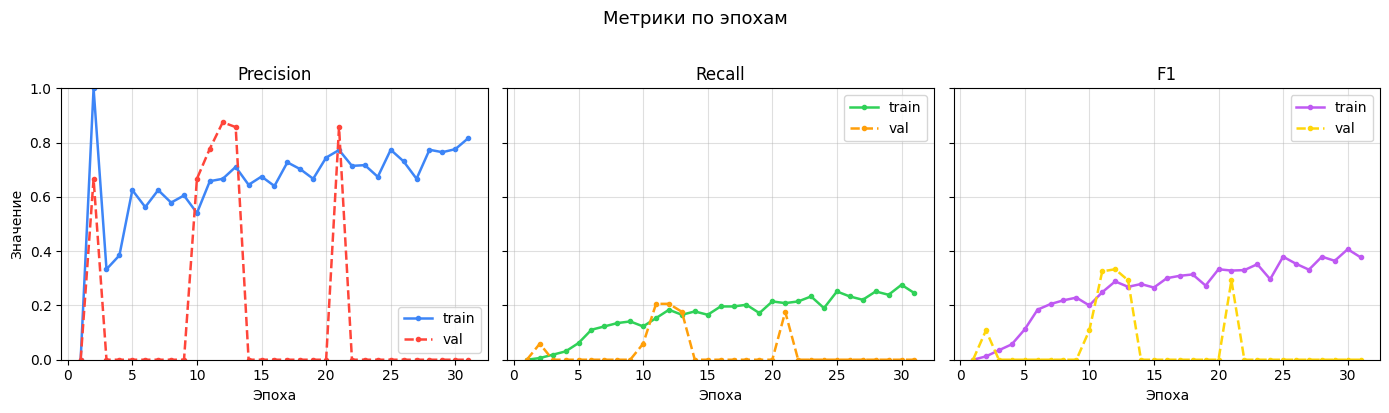

In [25]:
main()